In [ ]:
# mount your google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/Advanced_deep_learning')

In [ ]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
DATA_PATH = '/content/drive/My Drive/Advanced_deep_learning/Exercise_1'

In [ ]:
pip install git+https://github.com/thoglu/jammy_flows.git --no-deps

  Cloning https://github.com/thoglu/jammy_flows.git to /tmp/pip-req-build-r3u059y3
  Running command git clone --filter=blob:none --quiet https://github.com/thoglu/jammy_flows.git /tmp/pip-req-build-r3u059y3
  Resolved https://github.com/thoglu/jammy_flows.git to commit 3ec7872f8535b8e8db2e31f74a7c55bad5c54d5f
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
import jammy_flows
from scipy.stats import norm
import argparse
import glob
import subprocess

In [ ]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

In [ ]:
def normalize(labels, p):
    """
    Normalize the input labels using percentile-based scaling.

    This function scales the input labels to a range of [0, 1] based on the specified percentiles.
    The scaling is done by computing the percentiles of the labels and then normalizing the labels
    using these percentile values. The percentiles are decimals, we use these boundaries as the min/max
    of the dataset could be related to very rare data due to fluctuations, we want to identify a range
    in which are contained most of the data.

    Parameters:
    labels (np.ndarray): The input labels to be normalized.
    p (float): The percentile value used for scaling. The function uses the p-th and (1-p)-th percentiles
               for normalization.

    Returns:
    tuple: A tuple containing the normalized labels and the range used for normalization.
           - normalized_labels (np.ndarray): The normalized labels.
           - ranges (np.ndarray): The range used for normalization, which includes the p-th and (1-p)-th percentiles.
    """
    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

In [ ]:
# Function to denormalize the labels back to their original scale
def denormalize(labels, ranges):
    """
    Denormalize the input labels using the specified range.

    This function denormalizes the input labels using the specified range values.
    The denormalization is done by scaling the labels back to the original range
    using the provided range values.

    Parameters:
        labels (np.ndarray): The normalized labels to be  denormalized.
        ranges (np.ndarray): The range values used for normalization.

    Returns:
        np.ndarray: The denormalized labels.
    """
    return labels * (ranges[1] - ranges[0]) + ranges[0]


In [ ]:
def denormalize_std(uncertainty, ranges):
    """
    Denormalizes the given uncertainty predictions using the provided range.

    It is different to the denormalization of the labels which also includes a shift, as
    the uncertainty is a range and is independent from shifting.

    Parameters
    ----------
    uncertainty : array-like
        The normalized uncertainty to be denormalized.
    ranges : array-like
        A two-element array-like object where the first element is the minimum value
        and the second element is the maximum value of the original range.
    Returns
    -------
    array-like
        The denormalized uncertainty.
    """

    return uncertainty * (ranges[1] - ranges[0])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"I'm using: {device}")

I'm using: cuda


**Loading the "Spectra" dataset** $\to$ it contains data from measures of star spectra (features) and variables predictable from them (targets)

In [ ]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]*2 #Double the number of labels as now for each label the model has to predict also the associated gaussian uncertainty

In [ ]:
print(f'The "Spectra" dataset contains {spectra.shape[0]} spectra each with {spectra.shape[1]} measures.')
print(f'There are {labels.shape[0]} sets of labels') #Check if there are as many labels as spectra

The "Spectra" dataset contains 8914 spectra each with 16384 measures.
There are 8914 sets of labels


In [ ]:
# normalize the spectra: np.maximum forces all the values to be at least 0.2, and then the logarithm of the values is computed.
spectra = np.log(np.maximum(spectra, 0.2))

In [ ]:
#percentile normalization of labels: normalization ignoring the 5% lowest data and the 5% highest data. Returns normalized labels and ranges.
labels, range_norm = normalize(labels,0.05)

**Converting numpay array into PyTorch tensor**

In [ ]:
features = torch.from_numpy(spectra)
target = torch.from_numpy(labels)

print(features.device)

cpu


**Implementation of a CustomDataset class** $\to$ this approach allows to manage in a more efficient way the use of the device memory

In [ ]:
class CustomDataset(Dataset):
    def __init__(self,X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]

**Dividing the dataset in train, evaluate and test sets**

In [ ]:
dataset = CustomDataset(features, labels)

train_set, eval_set, test_set = random_split(dataset, [0.6, 0.2, 0.2])

In [ ]:
batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
eval_loader = DataLoader(eval_set, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

# 1. Diagonal Gaussian Normalizing Flow #

The free parameters of the normalizing flow are the mean and standard deviation of each of the three labels. This is equivalent to the previous exercise, but the mean and standard deviation is implemented by using an affine normalizing flow through the Jammy Flows package.

**Define the Autoencoder model** $\to$ as a model a CNN encoder which gives as an output the number of parameters of the normalizing flow is chosen

In [ ]:
class TinyCNNEncoder(nn.Module):
    def __init__(self, latent_dimension):
        super(TinyCNNEncoder, self).__init__()

        self.model = nn.Sequential(
            nn.Conv1d(1, 10, kernel_size=5), #Starting from 16384 data, default padding is '0': 12 output channels with 16384 data
			      nn.ReLU(),
			      nn.BatchNorm1d(10),
			      nn.Dropout(0.1),
			      nn.AvgPool1d(3), #Takes 3 and put the average value in the middle one, 12 output channels with 5460 data

			      nn.Conv1d(10, 20, kernel_size=5), #Good procedure to gradually double the number of output channels. 20 output channels with 5456 data.
			      nn.ReLU(),
			      nn.BatchNorm1d(20),
			      nn.Dropout(0.1),
			      nn.AvgPool1d(3), #Non divisible by three data number, elements not covered are ignored. 20 output channels with 1818 data.

			      nn.Conv1d(20, 40, kernel_size=5), #40 output channels with 1814 data.
			      nn.ReLU(),
			      nn.BatchNorm1d(40),
			      nn.Dropout(0.1),
			      nn.AvgPool1d(3), #40 output channels with 604 data.

			      nn.Conv1d(40, 10, kernel_size=1), #10 output channels with 604 data.
			      nn.ReLU(),
			      nn.BatchNorm1d(10),
			      nn.Dropout(0.1),
			      nn.AvgPool1d(2), #10 output channels with 302 data.

			      nn.Conv1d(10, 12, kernel_size=3), #12 output channels with 300 data.
			      nn.ReLU(),
			      nn.BatchNorm1d(12), #normalizes all the output of the layers to mean 0 and std 1
			      nn.Dropout(0.2), #randomly switches off 20% of neurons, in this way there are no predominant neurons on which the network depends strongly

			      nn.Conv1d(12, 10, kernel_size=1), #10 output channels with 300 data.
			      nn.Dropout(0.2),

			      nn.Linear(300, 32), # batch, filters, * -> batch, filters, 32: nn.Linear applies the same linear transformation to all the 10 channels indipendently, I get 10
            #output channels with 32 data each.
			      nn.ReLU(),
			      nn.Flatten(),
			      nn.Linear(10*32, 128),
			      nn.ReLU(),
			      nn.Linear(128, latent_dimension) #Output layer has the dimensione of the number of parameters of the normalizing flow
            )


    def forward(self, x):
        x = self.model(x)
        return x

In [ ]:
def nf_loss(input, batch_labels, model):
    """
    Computes the loss for a normalizing flow model. Here already the predictions of the model (log_pdf) are computed, no need to use forward function for training,
    in this case the forward is used only to predict parameters but in the training what counts is the value of the PDF, the neural network is not predicting the labels.

    Parameters
    ----------
    input : torch.Tensor
        The input data of the model.
    batch_labels : torch.Tensor
        The labels corresponding to the input data.
    model : torch.nn.Module
        The normalizing flow model used for evaluation.
    Returns
    -------
    torch.Tensor
        The computed loss value.
    """
    log_pdfs = model.log_pdf_evaluation(batch_labels, input) # get the probability of the labels given the input data
    loss = -log_pdfs.mean() # take the negative mean of the log probabilities
    return loss

**Defining the model which integrates the autoencoder model with the normalizing flow** $\to$ the model contains methods to sample the predicted distributions for each label, predict their mean and standard deviation, visualize the predicted PDFs,...

In [ ]:
fp64_on_cpu = False

In [ ]:
class CombinedModel(nn.Module):
    """
    A combined model that integrates a normalizing flow with a CNN encoder.
    """

    def __init__(self, encoder, nf_type="diagonal_gaussian"):
        """
        Initializes the normalizing flow model.

        Parameters
        ----------
        encoder : callable
            A function or callable object that returns an encoder model. The encoder model
            should take the number of flow parameters as input and output the latent dimension.
            I.e. the `TinyCNNEncoder` class defined above.
        nf_type : str, optional
            The type of normalizing flow to use. Options are "diagonal_gaussian", "full_gaussian",
            and "full_flow". Default is "diagonal_gaussian".
        Raises
        ------
        Exception
            If an unknown `nf_type` is provided.
        Notes
        -----
        This method sets up a 3-dimensional probability density function (PDF) over Euclidean space (e3)
        using the specified normalizing flow type. The flow structure and options are configured based on
        the provided `nf_type`. The PDF is created using the `jammy_flows` library, and the number of flow
        parameters is determined and printed. The encoder is initialized with the number of flow parameters.
        """

        super().__init__()

        # we define a 3-d PDF over Euclidean spae (e3)
        # using recommended settings (https://github.com/thoglu/jammy_flows/issues/5 scroll down)
        opt_dict = {}
        opt_dict["t"] = {}
        if (nf_type == "diagonal_gaussian"):
            opt_dict["t"]["cov_type"] = "diagonal"
            flow_defs = "t"
        elif (nf_type == "full_gaussian"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "t"
        elif (nf_type == "full_flow"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "gggt"
        else:
            raise Exception("Unknown nf type ", nf_type)

        opt_dict["g"] = dict()
        opt_dict["g"]["fit_normalization"] = 1
        opt_dict["g"]["upper_bound_for_widths"] = 1.0
        opt_dict["g"]["lower_bound_for_widths"] = 0.01

        self.nf_type = nf_type

        # 3d PDF (e3) with ggggt flow structure. Four Gaussianation-flow (https://arxiv.org/abs/2003.01941) layers ("g") and an affine flow ("t")
        self.pdf = jammy_flows.pdf("e3", flow_defs, options_overwrite=opt_dict,
                                   amortize_everything=True, amortization_mlp_use_custom_mode=True)

        # get the number of flow parameters
        num_flow_parameters = self.pdf.total_number_amortizable_params

        print("The normalizing flow has ", num_flow_parameters, " parameters...")

        # latent dimension (output of the CNN encoder) is set to the number of flow parameters
        self.encoder = encoder(num_flow_parameters)

    def log_pdf_evaluation(self, target_labels, input_data):
        """
        Evaluate the log probability density function (PDF) for the given target labels and input data.

        The normalizing flow parameters are predicted by the encoder network based on the input data.
        Then, the log PDF is evaluated at the position of the label.

        Parameters:
        -----------
        target_labels : torch.Tensor
            The target labels for which the log PDF is to be evaluated.
        input_data : torch.Tensor
            The input data to be encoded and used for evaluating the log PDF.
        Returns:
        --------
        log_pdf : torch.Tensor
            The evaluated log PDF for the given target labels and input data.
        """
        latent_intermediate = self.encoder(input_data)  # get the flow parameters from the CNN encoder

        if (self.nf_type == "full_flow"):
            # convert to double. Double precision is needed for the Gaussianization flow. This is for numerical stability.
            if fp64_on_cpu:  # MPS does not support double precision, therefore we need to run the flow on the CPU
                latent_intermediate = latent_intermediate.cpu().to(torch.float64)
                target_labels = target_labels.cpu().to(torch.float64)
            else:
                latent_intermediate = latent_intermediate.to(torch.float64)
                target_labels = target_labels.to(torch.float64)

        # evaluate the log PDF at the target labels
        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):
        """
        Sample new points from the PDF given input data. For every target the parameters predicted for the folw are different. We need to sample for every single
        distribution remembering from which distribution we sampled. The use of 'repeat interleave' allows to generate the samples for each target distribution
        in parallel, intead of generating all the samples for one target and then go to the next one.

        Parameters
        ----------
        flow_params : tensor
            Parameters for the normalizing flow, must be of shape (B, L) where B is the batch size and L is the latent dimension.
        samplesize_per_batchitem : int, optional
            Number of samples to draw per batch item. Defaults to 1000.

        Returns
        -------
        tensor
            A tensor of shape (B, S, D) where B is the batch dimension (position of the target in the given batch), S is the number of samples,
            and D is the dimension of the target space for the samples.
        """
        # for full flow we need to convert to double precision for the normalizing flow
        # for numerical stability
        if (self.nf_type == "full_flow"):
            # convert to double
            if fp64_on_cpu: # MPS does not support double precision, therefore we need to run the flow on the CPU
                flow_params = flow_params.cpu().to(torch.float64)
            else:
                flow_params = flow_params.to(torch.float64)

        batch_size = flow_params.shape[0] # get the batch size
        # sample from the normalizing flow
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(
            samplesize_per_batchitem, dim=0), allow_gradients=False)

        # reshape the samples to be grouped by batch item
        reshaped_samples = repeated_samples[:, None, :].view(
            batch_size, samplesize_per_batchitem, -1)

        return reshaped_samples

    def forward(self, input_data, samplesize_per_batchitem=1000):
        """
        Perform a forward pass through the model, predicting the mean and standard deviation of the samples.

        Normalizing flows do not directly predict the target labels. Instead, they predict the parameters of the flow that
        transforms the base distribution to the target distribution. Often, we still want to predict the target labels.
        Then, we can sample from the distribution and form the mean of the samples and their standard deviations.
        This is what this function does. This function is not used to compute the predictions in the training (for complex flows it doesn't return the number of
        parameters of the flow), it is only used to predict means and std.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor.
        Returns
        -------
        torch.Tensor
            A tensor of size (B, D*2) where the first half (size D) are the means,
            the second half (another D) are the standard deviations.
        """
        flow_params=self.encoder(input_data)
        samples=self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)

        # form mean along dim 1 (samples)
        means=samples.mean(dim=1)
        # form std along dim 1 (samples)
        std_deviations=samples.std(dim=1)

        # return means and std deviations as a concatenated tensor along dim 1: compute mean and std along dimensions, this method is very useful in diagonal gaussian
        #case but in other cases a more efficient way to deal with uncertainties should be designed
        return torch.cat([means, std_deviations], dim=1)

    def visualize_pdf(self, input_data, filename, samplesize=1000, batch_index=0, truth=None):
        """
        Visualizes the probability density function (PDF) of the given input data using a normalizing flow model.

        The function generates samples from the normalizing flow (using the sample() function)
        and plots the histogram of the samples together with a Gaussian approximation.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor from which to pick one batch item for visualization.
        filename : str
            The filename where the resulting plot will be saved.
        samplesize : int, optional
            The number of samples to generate for the PDF visualization (default is 10000).
        batch_index : int, optional
            The index of the batch item to visualize (default is 0).
        truth : torch.Tensor, optional
            The true values of the labels, used for comparison in the plot (default is None).

        Returns
        -------
        None
        """
        # pick out one input from batch, only one example to be visualized
        input_bitem = input_data[batch_index:batch_index+1]

        # get the flow parameters (by passing the input data through the CNN encoder network)
        flow_params = self.encoder(input_bitem)

        # sample from the normalizing flow (i.e. samples are drawn from the base distribution and transformed by the flow
        # using the change-of-variable formula)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)
        # the rest of the code is just plotting.

        # we only have 1 batch item
        samples = samples.squeeze(0)

        # plot three 1-dimensional distributions together with normal approximation,
        # so we calculate the mean and std of the samples
        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        fig, axdict = plt.subplots(3, 1, figsize = (10,10))
        for dim_ind in range(3):
            # plot the histogram of the samples
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True,
                                 bins=50, alpha=0.5, label="density based on samples")

            # plot the Gaussian approximation
            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green",
                                 label="Gaussian approximation")

            # plot the true value if it is given
            if (truth is not None):
                true_value = truth[dim_ind].cpu().item()
                axdict[dim_ind].axvline(
                    true_value, color="red", label="true value")

            # plot the legend only for the first panel
            if (dim_ind == 0):
                axdict[dim_ind].legend()

        plt.savefig(filename)
        plt.close(fig)


In [ ]:
# Model selection
model_choice = 'CombinedModel'

if model_choice == 'CombinedModel':
    model = CombinedModel(TinyCNNEncoder,"diagonal_gaussian")
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

model.to(device)

The normalizing flow has  6  parameters...


CombinedModel(
  (pdf): pdf(
    (layer_list): ModuleList(
      (0): ModuleList(
        (0): mvn_block()
      )
    )
    (mlp_predictors): ModuleList(
      (0): None
    )
  )
  (encoder): TinyCNNEncoder(
    (model): Sequential(
      (0): Conv1d(1, 10, kernel_size=(5,), stride=(1,))
      (1): ReLU()
      (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (5): Conv1d(10, 20, kernel_size=(5,), stride=(1,))
      (6): ReLU()
      (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): Dropout(p=0.1, inplace=False)
      (9): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (10): Conv1d(20, 40, kernel_size=(5,), stride=(1,))
      (11): ReLU()
      (12): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): Dropout(p=0.1, inplace=False)
      (14

**Training**

In [ ]:
N_epochs = 60
learning_rate = 0.0005

In [ ]:
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [ ]:
train_loss = []
eval_loss = []

#-------Training-------
for epoch in range(N_epochs):
  start_time = time.time()  # Start the timer for this epoch

  model.train()
  loss_val = []

  for step,(feature, label) in enumerate(train_loader):
    feature = feature.float().unsqueeze(1).to(device) #put data on GPU
    label = label.float().to(device)
    loss = nf_loss(feature,label,model) #loss computation
    loss_val.append(loss.item())

    optimizer.zero_grad() #clean the gradients computed at previous iteration
    loss.backward() #backpropagation
    optimizer.step() #weights update

     # Print progress every 10th step, updating the same line
    if (step + 1) % 10 == 0:
      sys.stdout.write(f"\rEpoch [{epoch + 1}/{N_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
      sys.stdout.flush()

  sys.stdout.write("\n")  # Move to the next line after the epoch
  train_loss.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
  with torch.no_grad():
    model.eval()
    loss_val = []
    for feature, label in eval_loader:
      feature = feature.float().unsqueeze(1).to(device)
      label = label.float().to(device)
      loss = nf_loss(feature,label,model)
      loss_val.append(loss.item())

    eval_loss.append(np.mean(loss_val))

#------------------------

Epoch [1/60], Step [40/42], Loss: -0.3162
Epoch [2/60], Step [40/42], Loss: -1.2974
Epoch [3/60], Step [40/42], Loss: -1.6882
Epoch [4/60], Step [40/42], Loss: -2.1038
Epoch [5/60], Step [40/42], Loss: -2.4349
Epoch [6/60], Step [40/42], Loss: -2.4662
Epoch [7/60], Step [40/42], Loss: -2.4030
Epoch [8/60], Step [40/42], Loss: -2.5547
Epoch [9/60], Step [40/42], Loss: -2.7171
Epoch [10/60], Step [40/42], Loss: -2.7465
Epoch [11/60], Step [40/42], Loss: -2.8224
Epoch [12/60], Step [40/42], Loss: -3.0689
Epoch [13/60], Step [40/42], Loss: -2.8787
Epoch [14/60], Step [40/42], Loss: -2.8145
Epoch [15/60], Step [40/42], Loss: -3.0933
Epoch [16/60], Step [40/42], Loss: -3.2752
Epoch [17/60], Step [40/42], Loss: -3.5377
Epoch [18/60], Step [40/42], Loss: -3.4885
Epoch [19/60], Step [40/42], Loss: -3.2438
Epoch [20/60], Step [40/42], Loss: -3.4441
Epoch [21/60], Step [40/42], Loss: -3.2203
Epoch [22/60], Step [40/42], Loss: -3.5012
Epoch [23/60], Step [40/42], Loss: -3.4341
Epoch [24/60], Step 

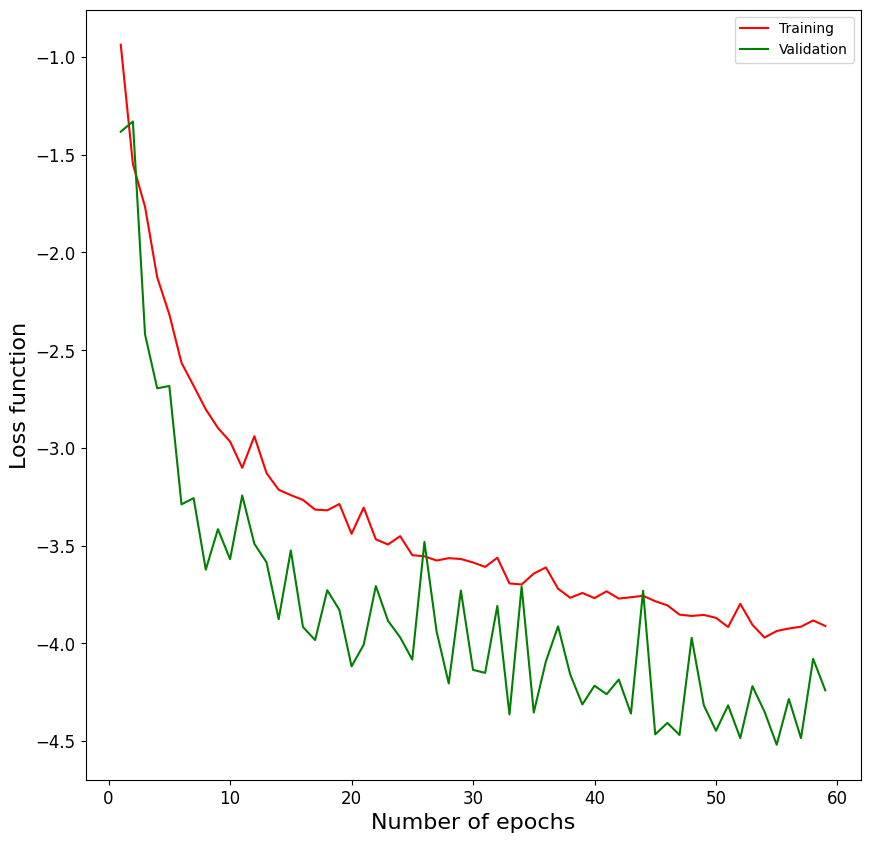

In [ ]:
plt.figure(figsize = (10,10))
plt.xlabel('Number of epochs')
plt.ylabel('Loss function')
plt.plot(np.array(range(N_epochs))[1:], train_loss[1:], color = 'red', label = 'Training') #Start from second element as the first epoch can give a very high loss
#value that makes the representation not clear
plt.plot(np.array(range(N_epochs))[1:], eval_loss[1:], color = 'green', label = 'Validation')
plt.legend(fontsize = 10)
plt.show()

**Testing** $\to$ evaluate mean and standard deviations using the function defined in the class

In [ ]:
predictions = []
labels = []
test_loss = []

with torch.no_grad():
  model.eval()
  for feature,label in test_loader:
    feature = feature.float().unsqueeze(1).to(device)
    label = label.float().to(device)
    pred = model(feature)
    loss = nf_loss(feature,label,model)
    test_loss.append(loss.item())
    predictions.append(pred.cpu().numpy())
    labels.append(label.cpu())

avrg_test_loss = np.mean(test_loss)
real = torch.cat(labels, dim=0).numpy()
predictions = np.concatenate(predictions, axis=0)

print(f'Average test loss: {avrg_test_loss:.4f}')

Average test loss: -4.1241


In [ ]:
denorm_predictions = denormalize(predictions[:,:3], range_norm)  # Denormalize predictions
denorm_std = denormalize_std(predictions[:,3:], range_norm) #Denormalize standard deviation, as the model predicts the logarithm to get the std the exponential must be computed
denorm_true_labels = denormalize(real, range_norm)  # Denormalize true labels

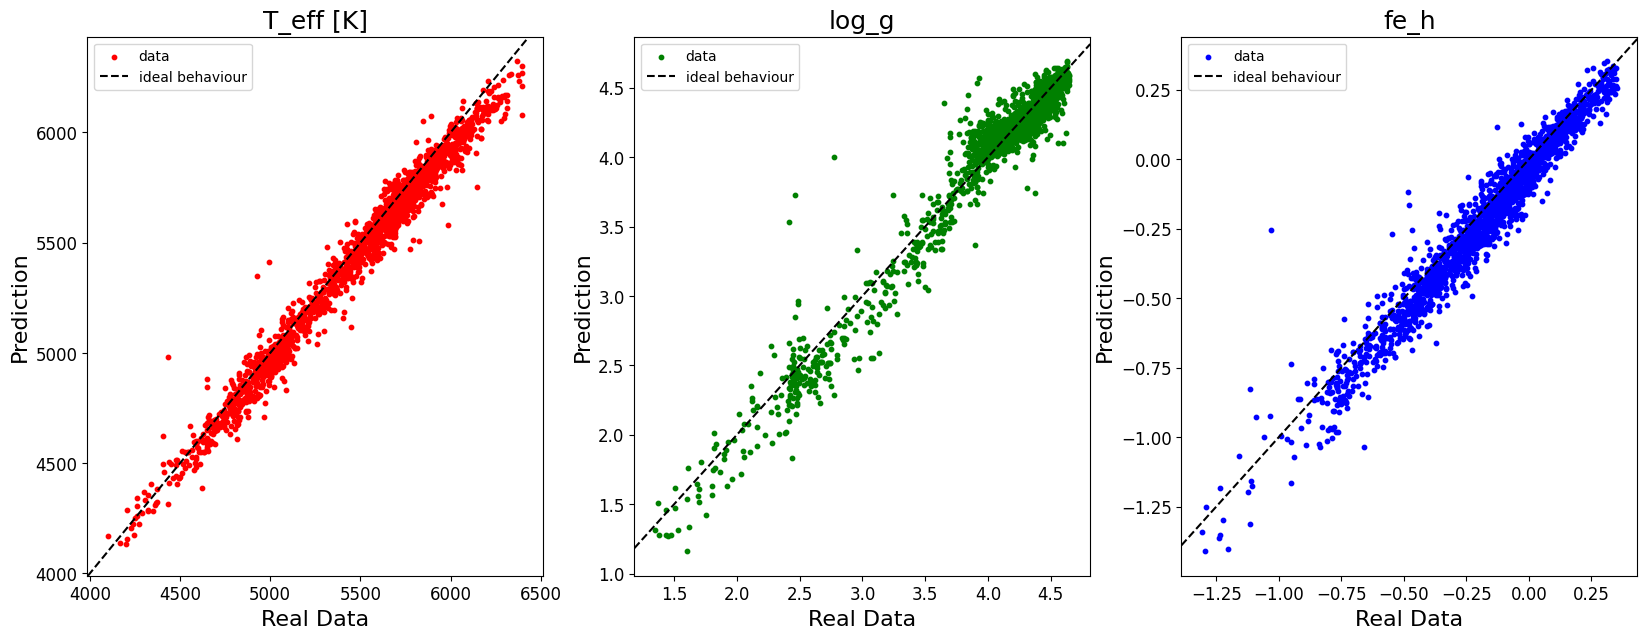

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20,7))
ax = ax.flatten()

ax[0].set_xlabel('Real Data')
ax[0].set_ylabel('Prediction')
ax[0].set_title('T_eff [K]')
ax[0].scatter(denorm_true_labels[:,0],denorm_predictions[:,0], color = 'red', s = 10, label = 'data')
ax[0].axline((denorm_true_labels[:,0].min(), denorm_true_labels[:,0].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[0].legend(fontsize = 10)

ax[1].set_xlabel('Real Data')
ax[1].set_ylabel('Prediction')
ax[1].set_title('log_g')
ax[1].scatter(denorm_true_labels[:,1],denorm_predictions[:,1], color = 'green', s = 10, label = 'data')
ax[1].axline((denorm_true_labels[:,1].min(), denorm_true_labels[:,1].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[1].legend(fontsize = 10)


ax[2].set_xlabel('Real Data')
ax[2].set_ylabel('Prediction')
ax[2].set_title('fe_h')
ax[2].scatter(denorm_true_labels[:,2],denorm_predictions[:,2], color = 'blue', s = 10, label = 'data')
ax[2].axline((denorm_true_labels[:,2].min(), denorm_true_labels[:,2].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[2].legend(fontsize = 10)

plt.show()

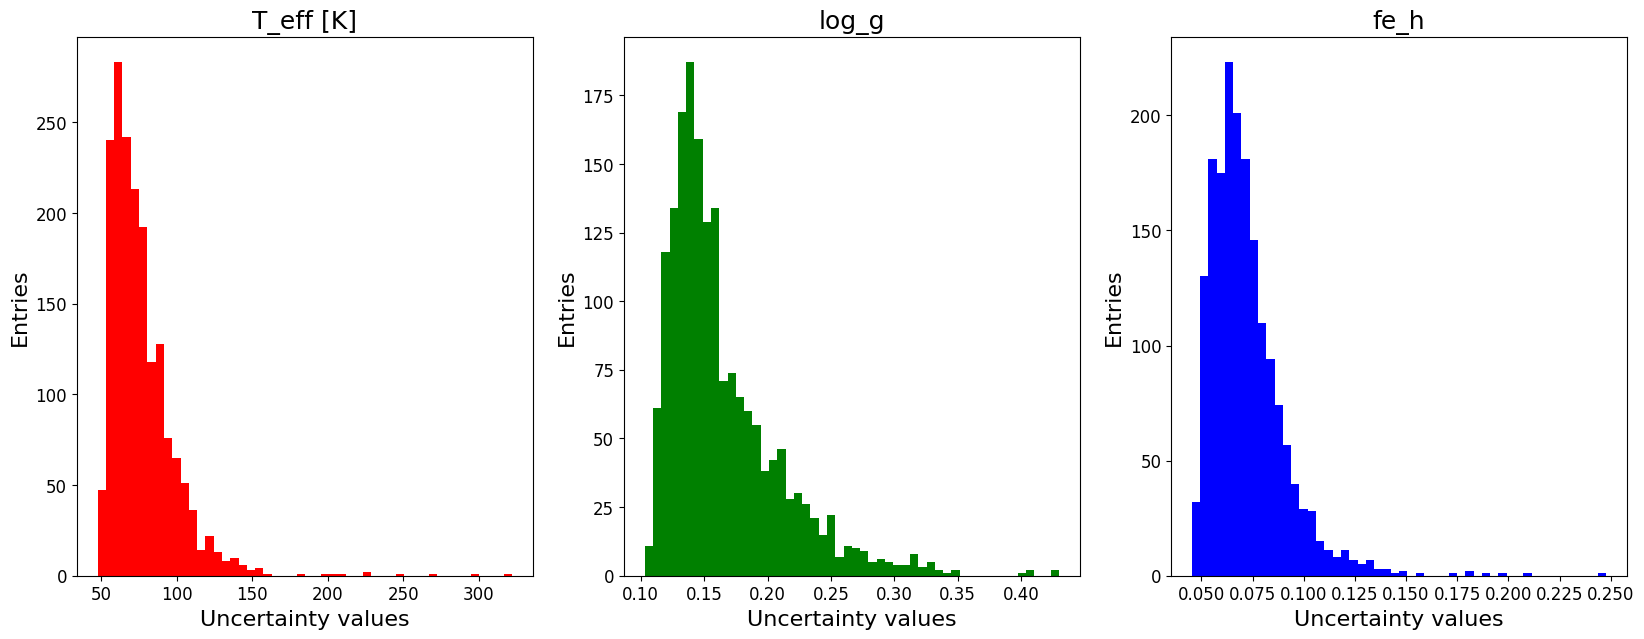

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20,7))
ax = ax.flatten()

ax[0].set_xlabel('Uncertainty values')
ax[0].set_ylabel('Entries')
ax[0].set_title('T_eff [K]')
ax[0].hist(denorm_std[:,0], bins = 50, color = 'red')

ax[1].set_xlabel('Uncertainty values')
ax[1].set_ylabel('Entries')
ax[1].set_title('log_g')
ax[1].hist(denorm_std[:,1], bins = 50, color = 'green')

ax[2].set_xlabel('Uncertainty values')
ax[2].set_ylabel('Entries')
ax[2].set_title('fe_h')
ax[2].hist(denorm_std[:,2], bins = 50, color = 'blue')

plt.show()

**Uncertainty validity check** $\to$ to check the validity of the obtained uncertainties, a possibility is to visualize the **"Pull Distribution** $$\frac{\mu_{pred}-label}{\sigma_{pred}}$$. Well-predicted uncertainties should be associated to a gaussian with mean zero and standard deviation 1.

In [ ]:
pull_val = (denorm_predictions - denorm_true_labels)/denorm_std

In [ ]:
counts_1, bin_edges_1 = np.histogram(pull_val[:,0], bins=50, density=True) #Obtain counts for the bins and bin limits for the gaussian fits of the histograms
counts_2, bin_edges_2 = np.histogram(pull_val[:,1], bins=50, density=True)
counts_3, bin_edges_3 = np.histogram(pull_val[:,2], bins=50, density=True)

In [ ]:
from scipy.stats import norm

mu_1, std_1 = norm.fit(pull_val[:,0]) #Built in function for gaussian fit of data, computes their mean and standard deviation
mu_2, std_2 = norm.fit(pull_val[:,1])
mu_3, std_3 = norm.fit(pull_val[:,2])

x_range_1 = np.linspace(bin_edges_1[0], bin_edges_1[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_1 = norm.pdf(x_range_1, mu_1, std_1) #Define points distributed on the computed gaussian for the defined range

x_range_2 = np.linspace(bin_edges_2[0], bin_edges_2[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_2 = norm.pdf(x_range_2, mu_2, std_2) #Define points distributed on the computed gaussian for the defined range

x_range_3 = np.linspace(bin_edges_3[0], bin_edges_3[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_3 = norm.pdf(x_range_3, mu_3, std_3) #Define points distributed on the computed gaussian for the defined range


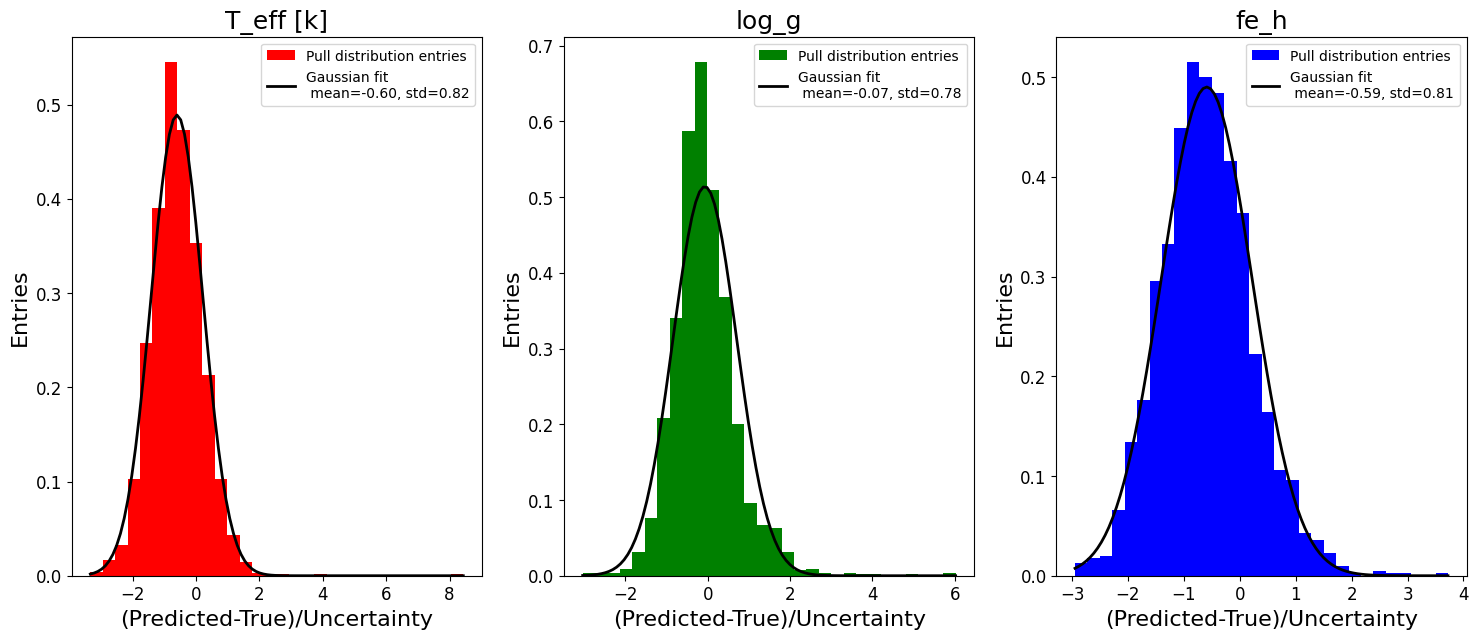

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (18,7))
ax = ax.flatten()

ax[0].hist(pull_val[:,0], bins=30, density=True, color='red', label = 'Pull distribution entries')
ax[0].plot(x_range_1, curve_fit_1, 'black', lw=2, label=f'Gaussian fit\n mean={mu_1:.2f}, std={std_1:.2f}')
ax[0].set_title('T_eff [k]')
ax[0].set_xlabel('(Predicted-True)/Uncertainty')
ax[0].set_ylabel('Entries')
ax[0].legend(fontsize = 10)

ax[1].hist(pull_val[:,1], bins=30, density=True, color='green', label = 'Pull distribution entries')
ax[1].plot(x_range_2, curve_fit_2, 'black', lw=2, label=f'Gaussian fit\n mean={mu_2:.2f}, std={std_2:.2f}')
ax[1].set_title('log_g')
ax[1].set_xlabel('(Predicted-True)/Uncertainty')
ax[1].set_ylabel('Entries')
ax[1].legend(fontsize = 10)

ax[2].hist(pull_val[:,2], bins=30, density=True, color='blue', label = 'Pull distribution entries')
ax[2].plot(x_range_3, curve_fit_3, 'black', lw=2, label=f'Gaussian fit\n mean={mu_3:.2f}, std={std_3:.2f}')
ax[2].set_title('fe_h')
ax[2].set_xlabel('(Predicted-True)/Uncertainty')
ax[2].set_ylabel('Entries')
ax[2].legend(fontsize = 10)

plt.show()

**Visualizing the predicted PDF** $\to$ visualization of some examples of predicted pdf using the function defined in the class: the grey histogram represents the distribution built related to the selected value, the green line represents the derived gaussian approzimation, the red line the real position of the selected value. The closer to the mean the value is, the better the prediction.

In [ ]:
import random

DATA_PATH_2 = '/content/drive/My Drive/Advanced_deep_learning/Exercise_3/'

model.eval()
with torch.no_grad():

    feature, label = next(iter(test_loader)) #Make the loader an iterable and extract the first available element

    feature = feature.unsqueeze(1).float().to(device)
    label = label.float().to(device)

    #Choose three different indexes to pick three random batch elements
    batch_size = feature.shape[0]
    random_indices = random.sample(range(batch_size), k=3)

    # Loop on indeces and visualize the Predicted PDFs
    for idx in random_indices:
        filename = f"{DATA_PATH_2}diagonal_gaussian_{idx}.png"

        model.visualize_pdf(
            input_data=feature,
            filename=filename,
            samplesize=2000,
            batch_index=idx,
            truth=label[idx]
        )

# 2. Full 3D Gaussian Normalizing Flow #

 The free parameters are the means of the three labels and the full covariance matrix between the three labels. From predicting indipendent gaussians for every label to predict a full gaussian that contain also information about labels correlation.


In [ ]:
# Model selection
model_choice = 'CombinedModel'

if model_choice == 'CombinedModel':
    model_2 = CombinedModel(TinyCNNEncoder,"full_gaussian")
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

model_2.to(device)

The normalizing flow has  9  parameters...


CombinedModel(
  (pdf): pdf(
    (layer_list): ModuleList(
      (0): ModuleList(
        (0): mvn_block()
      )
    )
    (mlp_predictors): ModuleList(
      (0): None
    )
  )
  (encoder): TinyCNNEncoder(
    (model): Sequential(
      (0): Conv1d(1, 10, kernel_size=(5,), stride=(1,))
      (1): ReLU()
      (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (5): Conv1d(10, 20, kernel_size=(5,), stride=(1,))
      (6): ReLU()
      (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): Dropout(p=0.1, inplace=False)
      (9): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (10): Conv1d(20, 40, kernel_size=(5,), stride=(1,))
      (11): ReLU()
      (12): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): Dropout(p=0.1, inplace=False)
      (14

**Training**

In [ ]:
N_epochs_2 = 60
learning_rate_2 = 0.0005

In [ ]:
optimizer_2 = optim.Adam(model_2.parameters(), lr = learning_rate_2)

In [ ]:
train_loss_2 = []
eval_loss_2 = []

#-------Training-------
for epoch in range(N_epochs_2):
  start_time = time.time()  # Start the timer for this epoch

  model_2.train()
  loss_val = []

  for step,(feature, label) in enumerate(train_loader):
    feature = feature.float().unsqueeze(1).to(device) #put data on GPU
    label = label.float().to(device)
    loss = nf_loss(feature,label,model_2) #loss computation
    loss_val.append(loss.item())

    optimizer_2.zero_grad() #clean the gradients computed at previous iteration
    loss.backward() #backpropagation
    optimizer_2.step() #weights update

     # Print progress every 10th step, updating the same line
    if (step + 1) % 10 == 0:
      sys.stdout.write(f"\rEpoch [{epoch + 1}/{N_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
      sys.stdout.flush()

  sys.stdout.write("\n")  # Move to the next line after the epoch
  train_loss_2.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
  with torch.no_grad():
    model_2.eval()
    loss_val = []
    for feature, label in eval_loader:
      feature = feature.float().unsqueeze(1).to(device)
      label = label.float().to(device)
      loss = nf_loss(feature,label,model_2)
      loss_val.append(loss.item())

    eval_loss_2.append(np.mean(loss_val))

#------------------------

Epoch [1/60], Step [40/42], Loss: -0.9344
Epoch [2/60], Step [40/42], Loss: -1.4332
Epoch [3/60], Step [40/42], Loss: -1.3565
Epoch [4/60], Step [40/42], Loss: -1.9270
Epoch [5/60], Step [40/42], Loss: -2.4269
Epoch [6/60], Step [40/42], Loss: -2.3892
Epoch [7/60], Step [40/42], Loss: -2.4339
Epoch [8/60], Step [40/42], Loss: -2.2855
Epoch [9/60], Step [40/42], Loss: -2.9577
Epoch [10/60], Step [40/42], Loss: -2.6173
Epoch [11/60], Step [40/42], Loss: -2.8187
Epoch [12/60], Step [40/42], Loss: -2.4746
Epoch [13/60], Step [40/42], Loss: -2.7530
Epoch [14/60], Step [40/42], Loss: -2.6552
Epoch [15/60], Step [40/42], Loss: -2.6630
Epoch [16/60], Step [40/42], Loss: -3.4233
Epoch [17/60], Step [40/42], Loss: -3.2580
Epoch [18/60], Step [40/42], Loss: -3.2831
Epoch [19/60], Step [40/42], Loss: -3.4011
Epoch [20/60], Step [40/42], Loss: -3.4151
Epoch [21/60], Step [40/42], Loss: -3.4377
Epoch [22/60], Step [40/42], Loss: -2.9883
Epoch [23/60], Step [40/42], Loss: -3.5237
Epoch [24/60], Step 

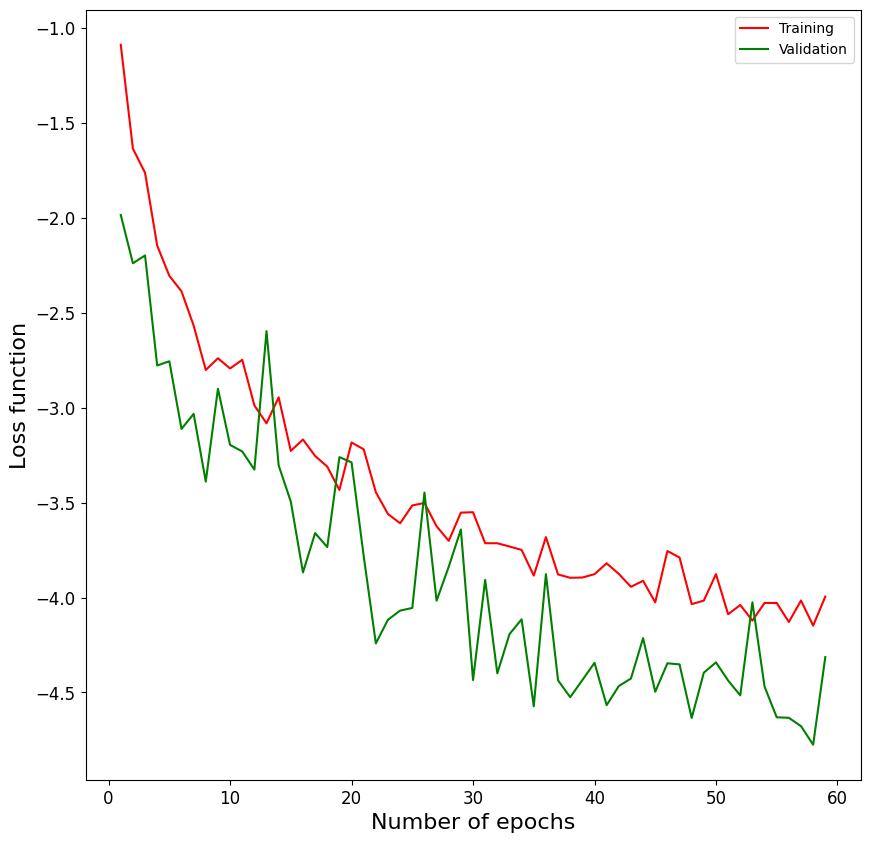

In [ ]:
plt.figure(figsize = (10,10))
plt.xlabel('Number of epochs')
plt.ylabel('Loss function')
plt.plot(np.array(range(N_epochs_2))[1:], train_loss_2[1:], color = 'red', label = 'Training')
plt.plot(np.array(range(N_epochs_2))[1:], eval_loss_2[1:], color = 'green', label = 'Validation')
plt.legend(fontsize = 10)
plt.show()

**Interpretation of results** $\to$ the model predicts 9 parameters. The first three are the means of the distributions along the axes of the three labels, the six after are the parameters of the "Cholesky matrix" L in the low triangle half. This matrix satisfies: $$\Sigma = L L^T$$ with $\Sigma$ the covariance matrix. The square root of the elements on the diagonal acan be considered as the predicted uncertainties. To evaluate the quality of uncertainties there are two possible ways:

* Compute the **Mahalanobis distance** $\to$ it is defined as $$D_M = \sqrt{(y-\mu)^T\Sigma^{-1}(y-\mu)}$$ and is the expression for the chi square for 3 degrees of liberty. The distribution of the $D_M^2$ values should be coherent with the function $\chi^2(3)$ and should be centered around 3.5 (value of chi square for which $68\%$ of data lie inside the related ellipsoid);
* Pull distribution $\to$ way to test the 1D gaussian distributions along the axes of the three labels.

In [ ]:
predictions_2 = []
labels_2 = []
test_loss_2 = []

with torch.no_grad():
  model.eval()
  for feature,label in test_loader:
    feature = feature.float().unsqueeze(1).to(device)
    label = label.float().to(device)
    flow_params = model_2.encoder(feature) #Extract the parameters of the normalizing flow
    loss = nf_loss(feature,label,model_2)
    test_loss_2.append(loss.item())
    predictions_2.append(flow_params.cpu())
    labels_2.append(label.cpu())

avrg_test_loss_2 = np.mean(test_loss_2)
real_2 = torch.cat(labels_2, dim=0).numpy()
predictions_2 = torch.cat(predictions_2,dim=0).numpy()

print(f'Average test loss: {avrg_test_loss_2:.4f}')

Average test loss: -4.2415


**Compute the covariance matrix** and the uncertainties

In [ ]:
means = predictions_2[:,:3]
cholesky_m = predictions_2[:,3:]
sigmas = []
covariance_matrices = []

for i in range(cholesky_m.shape[0]):
  covariance = []
  sigma = []
  L = np.zeros((3,3))
  L[0,0] = np.exp(cholesky_m[i,0])
  L[1,1] = np.exp(cholesky_m[i,1])
  L[2,2] = np.exp(cholesky_m[i,2])
  L[1,0] = cholesky_m[i,3]
  L[2,0] = cholesky_m[i,4]
  L[2,1] = cholesky_m[i,5]

  covariance_m = np.dot(L,L.T)
  sigma.append(np.sqrt(covariance_m[0,0]))
  sigma.append(np.sqrt(covariance_m[1,1]))
  sigma.append(np.sqrt(covariance_m[2,2]))

  sigmas.append(sigma)
  covariance_matrices.append(covariance_m)

sigmas = np.array(sigmas)
covariance_matrices = np.array(covariance_matrices)

In [ ]:
denorm_sigmas = denormalize_std(sigmas,range_norm)
denorm_predictions_2 = denormalize(means,range_norm)
denorm_true_labels_2 = denormalize(real_2,range_norm)

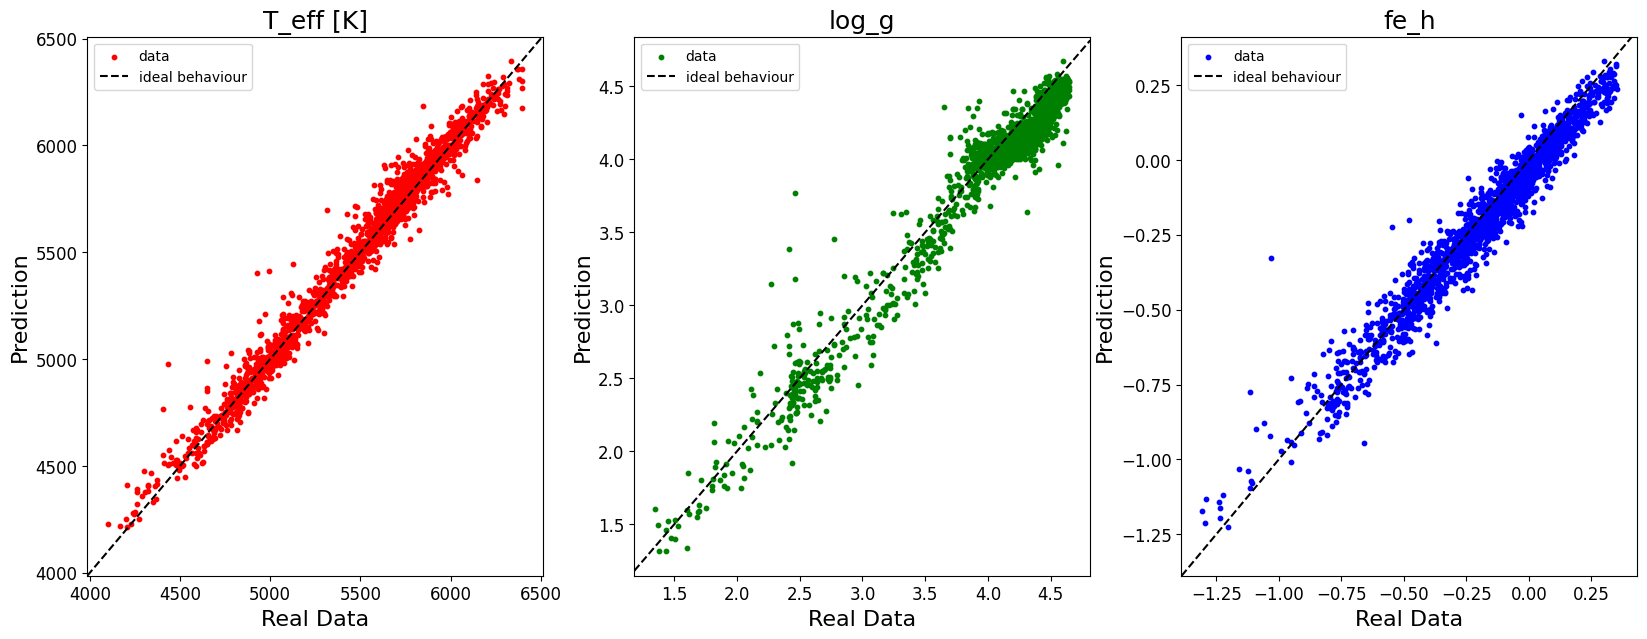

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20,7))
ax = ax.flatten()

ax[0].set_xlabel('Real Data')
ax[0].set_ylabel('Prediction')
ax[0].set_title('T_eff [K]')
ax[0].scatter(denorm_true_labels_2[:,0],denorm_predictions_2[:,0], color = 'red', s = 10, label = 'data')
ax[0].axline((denorm_true_labels_2[:,0].min(), denorm_true_labels_2[:,0].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[0].legend(fontsize = 10)

ax[1].set_xlabel('Real Data')
ax[1].set_ylabel('Prediction')
ax[1].set_title('log_g')
ax[1].scatter(denorm_true_labels_2[:,1],denorm_predictions_2[:,1], color = 'green', s = 10, label = 'data')
ax[1].axline((denorm_true_labels_2[:,1].min(), denorm_true_labels_2[:,1].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[1].legend(fontsize = 10)


ax[2].set_xlabel('Real Data')
ax[2].set_ylabel('Prediction')
ax[2].set_title('fe_h')
ax[2].scatter(denorm_true_labels_2[:,2],denorm_predictions_2[:,2], color = 'blue', s = 10, label = 'data')
ax[2].axline((denorm_true_labels_2[:,2].min(), denorm_true_labels_2[:,2].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[2].legend(fontsize = 10)

plt.show()

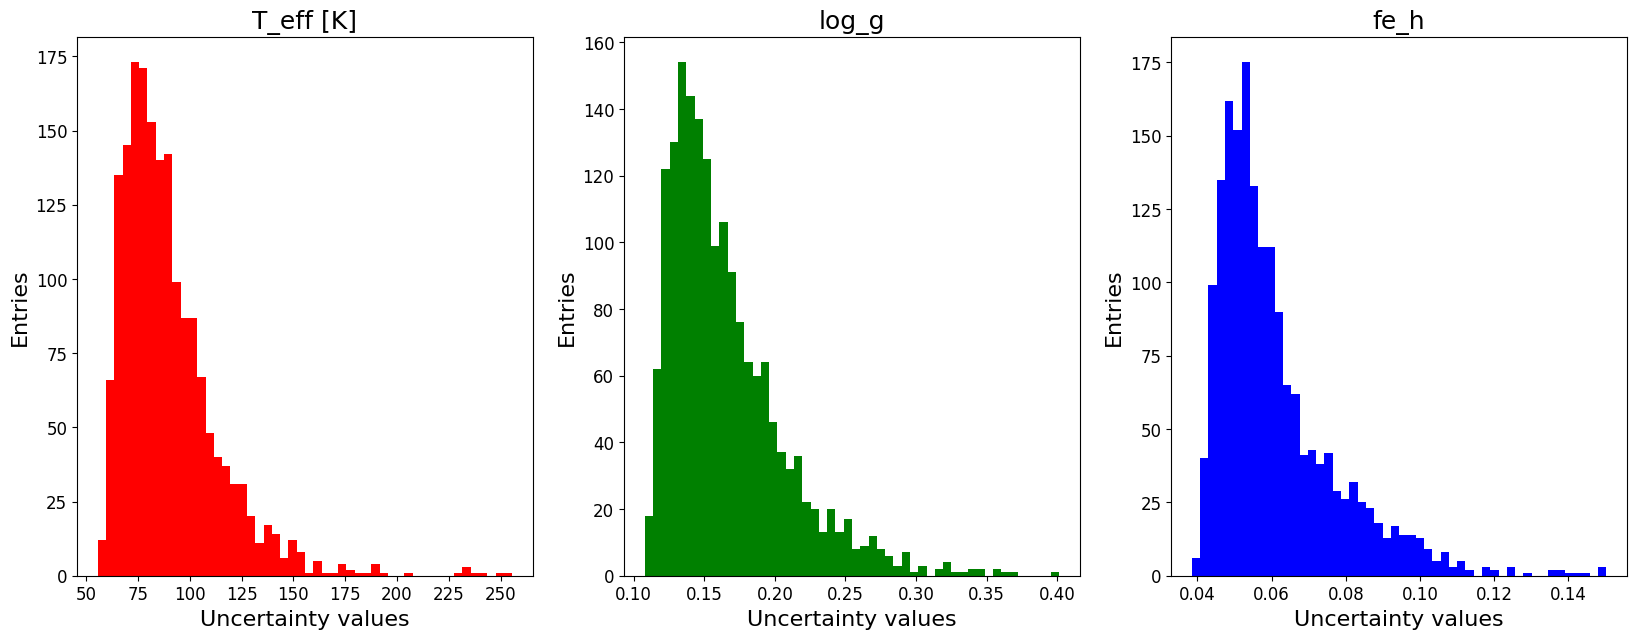

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20,7))
ax = ax.flatten()

ax[0].set_xlabel('Uncertainty values')
ax[0].set_ylabel('Entries')
ax[0].set_title('T_eff [K]')
ax[0].hist(denorm_sigmas[:,0], bins = 50, color = 'red')

ax[1].set_xlabel('Uncertainty values')
ax[1].set_ylabel('Entries')
ax[1].set_title('log_g')
ax[1].hist(denorm_sigmas[:,1], bins = 50, color = 'green')

ax[2].set_xlabel('Uncertainty values')
ax[2].set_ylabel('Entries')
ax[2].set_title('fe_h')
ax[2].hist(denorm_sigmas[:,2], bins = 50, color = 'blue')

plt.show()

**Mahalanobis distance**

In [ ]:
from scipy.stats import chi2

dm_squared = []

for i in range(denorm_true_labels_2.shape[0]):
  diff = real_2[i] - means[i] #Use not denormalized data, as the covariance matrix is not denormalized: as the result is a number, it is not influenced by normalization
  Sigma = covariance_matrices[i]
  x = np.linalg.solve(Sigma, diff) #solution of Sigma*x = diff i.e. x = inv(Sigma)*diff
  dm_squared.append(np.dot(diff, x))

x = np.linspace(0, 15, 500)
true_chi_func = chi2.pdf(x, 3)

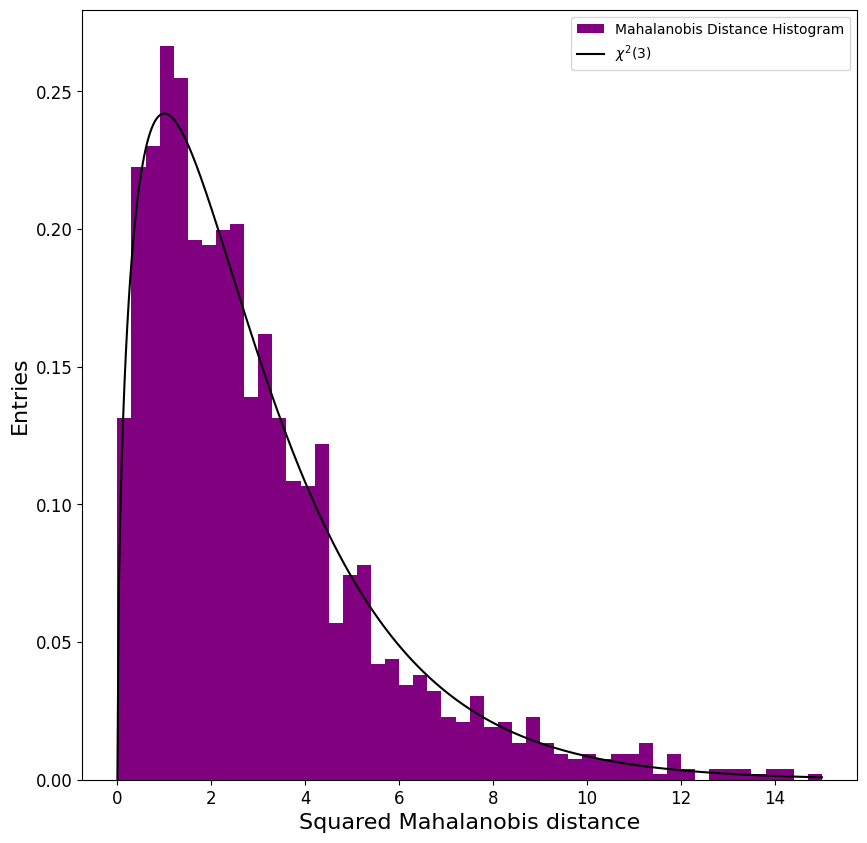

In [ ]:
plt.figure(figsize  = (10,10))
plt.xlabel('Squared Mahalanobis distance')
plt.ylabel('Entries')
plt.hist(dm_squared,bins=50,color='purple', range = (0,15),density=True,label='Mahalanobis Distance Histogram')
plt.plot(x,true_chi_func,color='black',label=r'$\chi^2(3)$')
plt.legend(fontsize = 10)

plt.show()

**Pull distribution**

In [ ]:
pull_val_2 = (denorm_predictions_2 - denorm_true_labels_2)/denorm_sigmas

In [ ]:
counts_1_2, bin_edges_1_2 = np.histogram(pull_val_2[:,0], bins=50, density=True) #Obtain counts for the bins and bin limits for the gaussian fits of the histograms
counts_2_2, bin_edges_2_2 = np.histogram(pull_val_2[:,1], bins=50, density=True)
counts_3_2, bin_edges_3_2 = np.histogram(pull_val_2[:,2], bins=50, density=True)

In [ ]:
from scipy.stats import norm

mu_1_2, std_1_2 = norm.fit(pull_val_2[:,0]) #Built in function for gaussian fit of data, computes their mean and standard deviation
mu_2_2, std_2_2 = norm.fit(pull_val_2[:,1])
mu_3_2, std_3_2 = norm.fit(pull_val_2[:,2])

x_range_1_2 = np.linspace(bin_edges_1_2[0], bin_edges_1_2[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_1_2 = norm.pdf(x_range_1_2, mu_1_2, std_1_2) #Define points distributed on the computed gaussian for the defined range

x_range_2_2 = np.linspace(bin_edges_2_2[0], bin_edges_2_2[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_2_2 = norm.pdf(x_range_2_2, mu_2_2, std_2_2) #Define points distributed on the computed gaussian for the defined range

x_range_3_2 = np.linspace(bin_edges_3_2[0], bin_edges_3_2[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_3_2 = norm.pdf(x_range_3_2, mu_3, std_3_2) #Define points distributed on the computed gaussian for the defined range


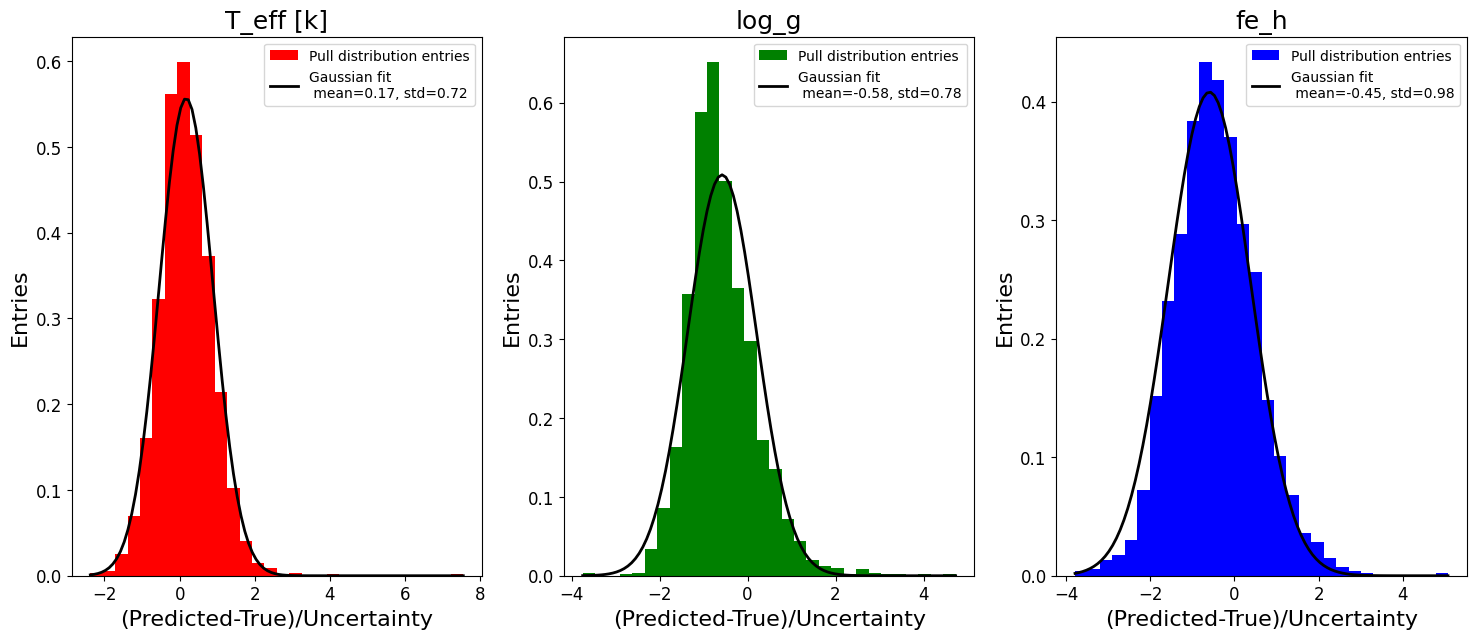

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (18,7))
ax = ax.flatten()

ax[0].hist(pull_val_2[:,0], bins=30, density=True, color='red', label = 'Pull distribution entries')
ax[0].plot(x_range_1_2, curve_fit_1_2, 'black', lw=2, label=f'Gaussian fit\n mean={mu_1_2:.2f}, std={std_1_2:.2f}')
ax[0].set_title('T_eff [k]')
ax[0].set_xlabel('(Predicted-True)/Uncertainty')
ax[0].set_ylabel('Entries')
ax[0].legend(fontsize = 10)

ax[1].hist(pull_val_2[:,1], bins=30, density=True, color='green', label = 'Pull distribution entries')
ax[1].plot(x_range_2_2, curve_fit_2_2, 'black', lw=2, label=f'Gaussian fit\n mean={mu_2_2:.2f}, std={std_2_2:.2f}')
ax[1].set_title('log_g')
ax[1].set_xlabel('(Predicted-True)/Uncertainty')
ax[1].set_ylabel('Entries')
ax[1].legend(fontsize = 10)

ax[2].hist(pull_val_2[:,2], bins=30, density=True, color='blue', label = 'Pull distribution entries')
ax[2].plot(x_range_3_2, curve_fit_3_2, 'black', lw=2, label=f'Gaussian fit\n mean={mu_3_2:.2f}, std={std_3_2:.2f}')
ax[2].set_title('fe_h')
ax[2].set_xlabel('(Predicted-True)/Uncertainty')
ax[2].set_ylabel('Entries')
ax[2].legend(fontsize = 10)

plt.show()

**Predicted PDF visualization**

In [ ]:
model_2.eval()
with torch.no_grad():

    feature, label = next(iter(test_loader)) #Make the loader an iterable and extract the first available element

    feature = feature.unsqueeze(1).float().to(device)
    label = label.float().to(device)

    #Choose three different indexes to pick three random batch elements
    batch_size = feature.shape[0]
    random_indices = random.sample(range(batch_size), k=3)

    # Loop on indeces and visualize the Predicted PDFs
    for idx in random_indices:
        filename = f"{DATA_PATH_2}full_gaussian_{idx}.png"

        model_2.visualize_pdf(
            input_data=feature,
            filename=filename,
            samplesize=2000,
            batch_index=idx,
            truth=label[idx]
        )

# 3. Normalizing Flow consisting of several Gaussianization Flows plus one Affine Flow #

The parameters of the flow now are many and they are not relatable directly to the uncertainty. The errors will be estimated as the standard deviations of the predicted distributions using the sampling method already considered in the first case of diagonal gaussians.

In [ ]:
# Model selection
model_choice = 'CombinedModel'

if model_choice == 'CombinedModel':
    model_3 = CombinedModel(TinyCNNEncoder,"full_flow")
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

model_3.to(device)

The normalizing flow has  306  parameters...


CombinedModel(
  (pdf): pdf(
    (layer_list): ModuleList(
      (0): ModuleList(
        (0-2): 3 x gf_block()
        (3): mvn_block()
      )
    )
    (mlp_predictors): ModuleList(
      (0): None
    )
  )
  (encoder): TinyCNNEncoder(
    (model): Sequential(
      (0): Conv1d(1, 10, kernel_size=(5,), stride=(1,))
      (1): ReLU()
      (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (5): Conv1d(10, 20, kernel_size=(5,), stride=(1,))
      (6): ReLU()
      (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): Dropout(p=0.1, inplace=False)
      (9): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (10): Conv1d(20, 40, kernel_size=(5,), stride=(1,))
      (11): ReLU()
      (12): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): Dropout(p

**Training**

In [ ]:
N_epochs_3 = 60
learning_rate_3 = 0.0005

In [ ]:
optimizer_3 = optim.Adam(model_3.parameters(), lr = learning_rate_3)

In [ ]:
train_loss_3 = []
eval_loss_3 = []

#-------Training-------
for epoch in range(N_epochs_3):
  start_time = time.time()  # Start the timer for this epoch

  model_3.train()
  loss_val = []

  for step,(feature, label) in enumerate(train_loader):
    feature = feature.float().unsqueeze(1).to(device) #put data on GPU
    label = label.float().to(device)
    loss = nf_loss(feature,label,model_3) #loss computation
    loss_val.append(loss.item())

    optimizer_3.zero_grad() #clean the gradients computed at previous iteration
    loss.backward() #backpropagation
    optimizer_3.step() #weights update

     # Print progress every 10th step, updating the same line
    if (step + 1) % 10 == 0:
      sys.stdout.write(f"\rEpoch [{epoch + 1}/{N_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
      sys.stdout.flush()

  sys.stdout.write("\n")  # Move to the next line after the epoch
  train_loss_3.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
  with torch.no_grad():
    model_3.eval()
    loss_val = []
    for feature, label in eval_loader:
      feature = feature.float().unsqueeze(1).to(device)
      label = label.float().to(device)
      loss = nf_loss(feature,label,model_3)
      loss_val.append(loss.item())

    eval_loss_3.append(np.mean(loss_val))

#------------------------

Epoch [1/60], Step [40/42], Loss: -0.0672
Epoch [2/60], Step [40/42], Loss: -1.1563
Epoch [3/60], Step [40/42], Loss: -1.4326
Epoch [4/60], Step [40/42], Loss: -2.0776
Epoch [5/60], Step [40/42], Loss: -1.6510
Epoch [6/60], Step [40/42], Loss: -2.5906
Epoch [7/60], Step [40/42], Loss: -3.2226
Epoch [8/60], Step [40/42], Loss: -2.6168
Epoch [9/60], Step [40/42], Loss: -3.3368
Epoch [10/60], Step [40/42], Loss: -3.0853
Epoch [11/60], Step [40/42], Loss: -3.2797
Epoch [12/60], Step [40/42], Loss: -2.6376
Epoch [13/60], Step [40/42], Loss: -3.5819
Epoch [14/60], Step [40/42], Loss: -3.5727
Epoch [15/60], Step [40/42], Loss: -3.5146
Epoch [16/60], Step [40/42], Loss: -3.5885
Epoch [17/60], Step [40/42], Loss: -3.7831
Epoch [18/60], Step [40/42], Loss: -3.0753
Epoch [19/60], Step [40/42], Loss: -3.6874
Epoch [20/60], Step [40/42], Loss: -3.9160
Epoch [21/60], Step [40/42], Loss: -3.8189
Epoch [22/60], Step [40/42], Loss: -3.8928
Epoch [23/60], Step [40/42], Loss: -3.9691
Epoch [24/60], Step 

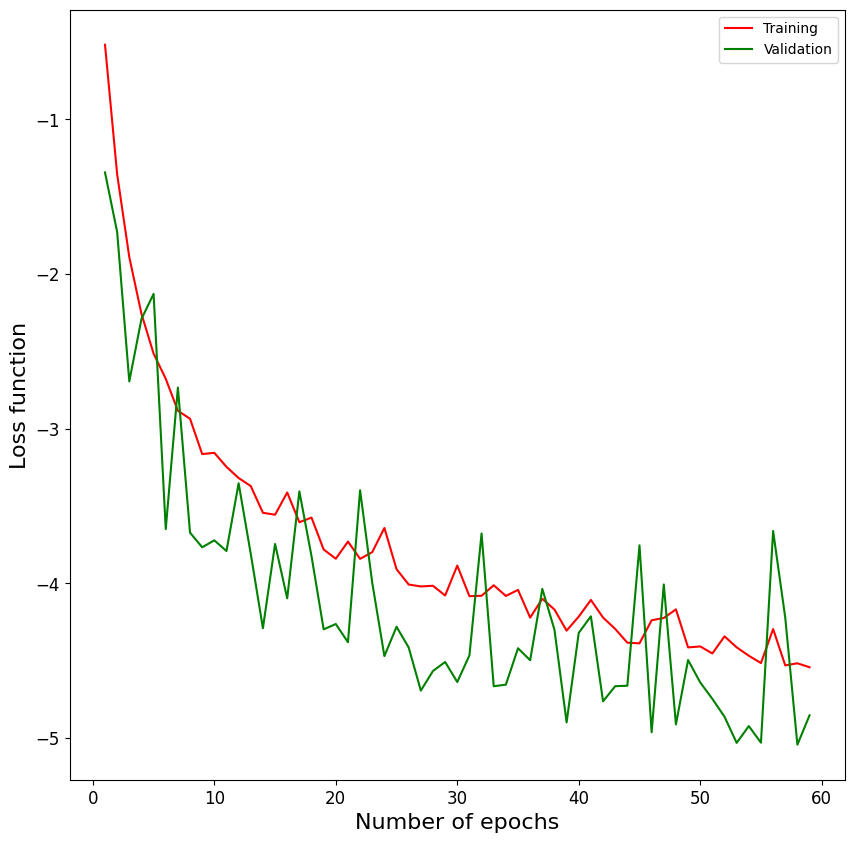

In [ ]:
plt.figure(figsize = (10,10))
plt.xlabel('Number of epochs')
plt.ylabel('Loss function')
plt.plot(np.array(range(N_epochs_3))[1:], train_loss_3[1:], color = 'red', label = 'Training')
plt.plot(np.array(range(N_epochs_3))[1:], eval_loss_3[1:], color = 'green', label = 'Validation')
plt.legend(fontsize = 10)
plt.show()

**Testing**

In [ ]:
predictions_3 = []
labels_3 = []
test_loss_3 = []

with torch.no_grad():
  model_3.eval()
  for feature,label in test_loader:
    feature = feature.float().unsqueeze(1).to(device)
    label = label.float().to(device)
    pred = model_3(feature) #return mean and std of the predicted distributions for every label through sampling
    loss = nf_loss(feature,label,model_3)
    test_loss.append(loss.item())
    predictions_3.append(pred.cpu().numpy())
    labels_3.append(label.cpu())

avrg_test_loss_3 = np.mean(test_loss)
real_3 = torch.cat(labels_3, dim=0).numpy()
predictions_3 = np.concatenate(predictions_3, axis=0)

print(f'Average test loss: {avrg_test_loss_3:.4f}')

Average test loss: -4.4641


In [ ]:
denorm_predictions_3 = denormalize(predictions_3[:,:3], range_norm)  # Denormalize predictions
denorm_std_3 = denormalize_std(predictions_3[:,3:], range_norm) #Denormalize standard deviation, as the model predicts the logarithm to get the std the exponential must be computed
denorm_true_labels_3 = denormalize(real_3, range_norm)  # Denormalize true labels

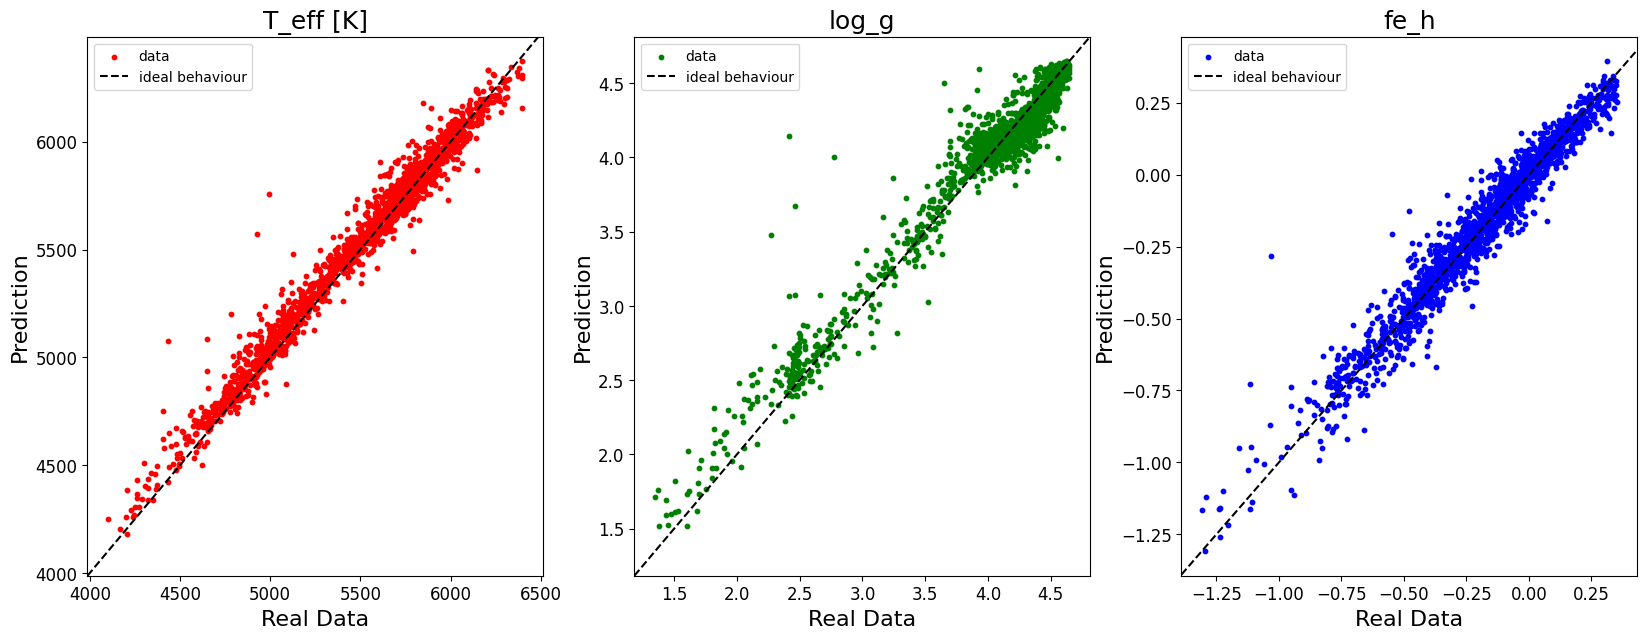

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20,7))
ax = ax.flatten()

ax[0].set_xlabel('Real Data')
ax[0].set_ylabel('Prediction')
ax[0].set_title('T_eff [K]')
ax[0].scatter(denorm_true_labels_3[:,0],denorm_predictions_3[:,0], color = 'red', s = 10, label = 'data')
ax[0].axline((denorm_true_labels_3[:,0].min(), denorm_true_labels_3[:,0].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[0].legend(fontsize = 10)

ax[1].set_xlabel('Real Data')
ax[1].set_ylabel('Prediction')
ax[1].set_title('log_g')
ax[1].scatter(denorm_true_labels_3[:,1],denorm_predictions_3[:,1], color = 'green', s = 10, label = 'data')
ax[1].axline((denorm_true_labels_3[:,1].min(), denorm_true_labels_3[:,1].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[1].legend(fontsize = 10)


ax[2].set_xlabel('Real Data')
ax[2].set_ylabel('Prediction')
ax[2].set_title('fe_h')
ax[2].scatter(denorm_true_labels_3[:,2],denorm_predictions_3[:,2], color = 'blue', s = 10, label = 'data')
ax[2].axline((denorm_true_labels_3[:,2].min(), denorm_true_labels_3[:,2].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[2].legend(fontsize = 10)

plt.show()

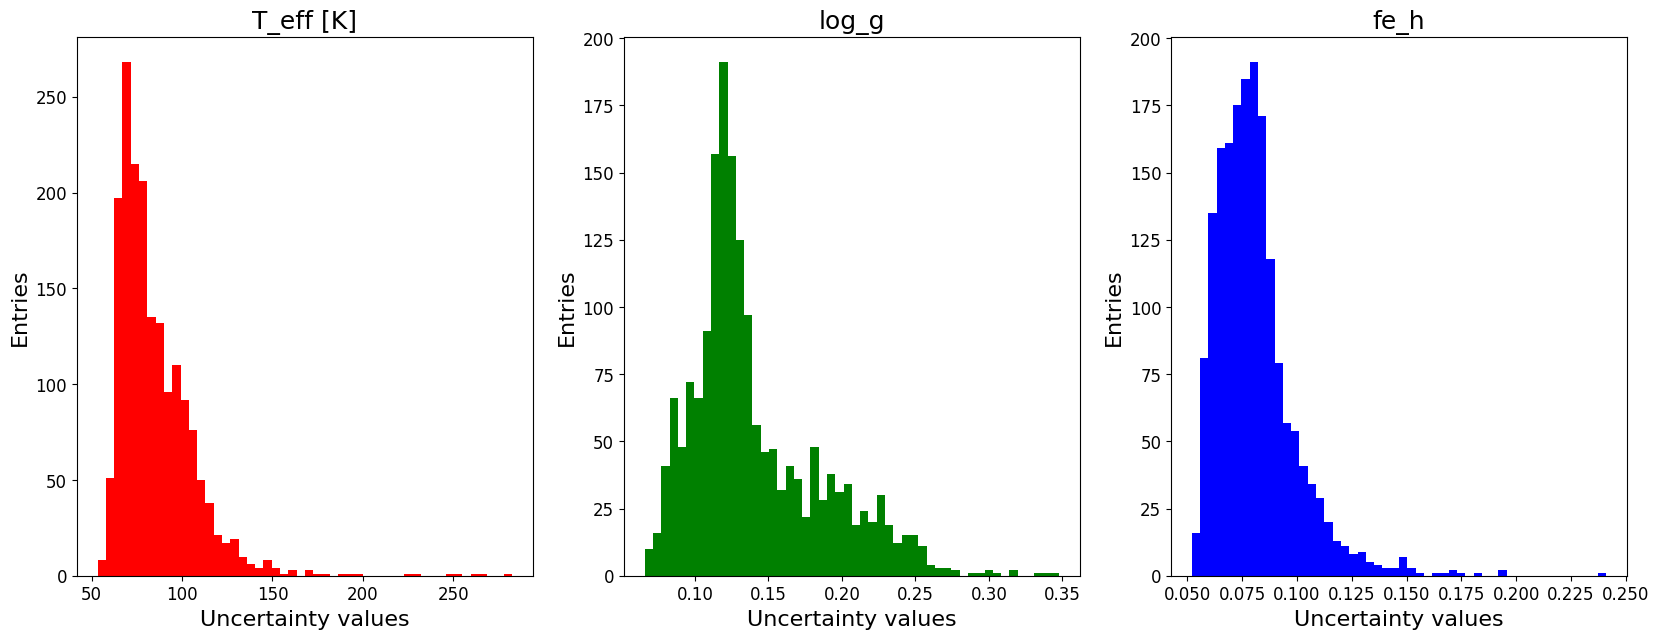

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20,7))
ax = ax.flatten()

ax[0].set_xlabel('Uncertainty values')
ax[0].set_ylabel('Entries')
ax[0].set_title('T_eff [K]')
ax[0].hist(denorm_std_3[:,0], bins = 50, color = 'red')

ax[1].set_xlabel('Uncertainty values')
ax[1].set_ylabel('Entries')
ax[1].set_title('log_g')
ax[1].hist(denorm_std_3[:,1], bins = 50, color = 'green')

ax[2].set_xlabel('Uncertainty values')
ax[2].set_ylabel('Entries')
ax[2].set_title('fe_h')
ax[2].hist(denorm_std_3[:,2], bins = 50, color = 'blue')

plt.show()

**Pull distribution**

In [ ]:
pull_val_3 = (denorm_predictions_3 - denorm_true_labels_3)/denorm_std_3

In [ ]:
counts_1_3, bin_edges_1_3 = np.histogram(pull_val_3[:,0], bins=50, density=True) #Obtain counts for the bins and bin limits for the gaussian fits of the histograms
counts_2_3, bin_edges_2_3 = np.histogram(pull_val_3[:,1], bins=50, density=True)
counts_3_3, bin_edges_3_3 = np.histogram(pull_val_3[:,2], bins=50, density=True)

In [ ]:
from scipy.stats import norm

mu_1_3, std_1_3 = norm.fit(pull_val_3[:,0]) #Built in function for gaussian fit of data, computes their mean and standard deviation
mu_2_3, std_2_3 = norm.fit(pull_val_3[:,1])
mu_3_3, std_3_3 = norm.fit(pull_val_3[:,2])

x_range_1_3 = np.linspace(bin_edges_1_3[0], bin_edges_1_3[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_1_3 = norm.pdf(x_range_1_3, mu_1_3, std_1_3) #Define points distributed on the computed gaussian for the defined range

x_range_2_3 = np.linspace(bin_edges_2_3[0], bin_edges_2_3[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_2_3 = norm.pdf(x_range_2_3, mu_2_3, std_2_3) #Define points distributed on the computed gaussian for the defined range

x_range_3_3 = np.linspace(bin_edges_3_3[0], bin_edges_3_3[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_3_3 = norm.pdf(x_range_3_3, mu_3_3, std_3_3) #Define points distributed on the computed gaussian for the defined range


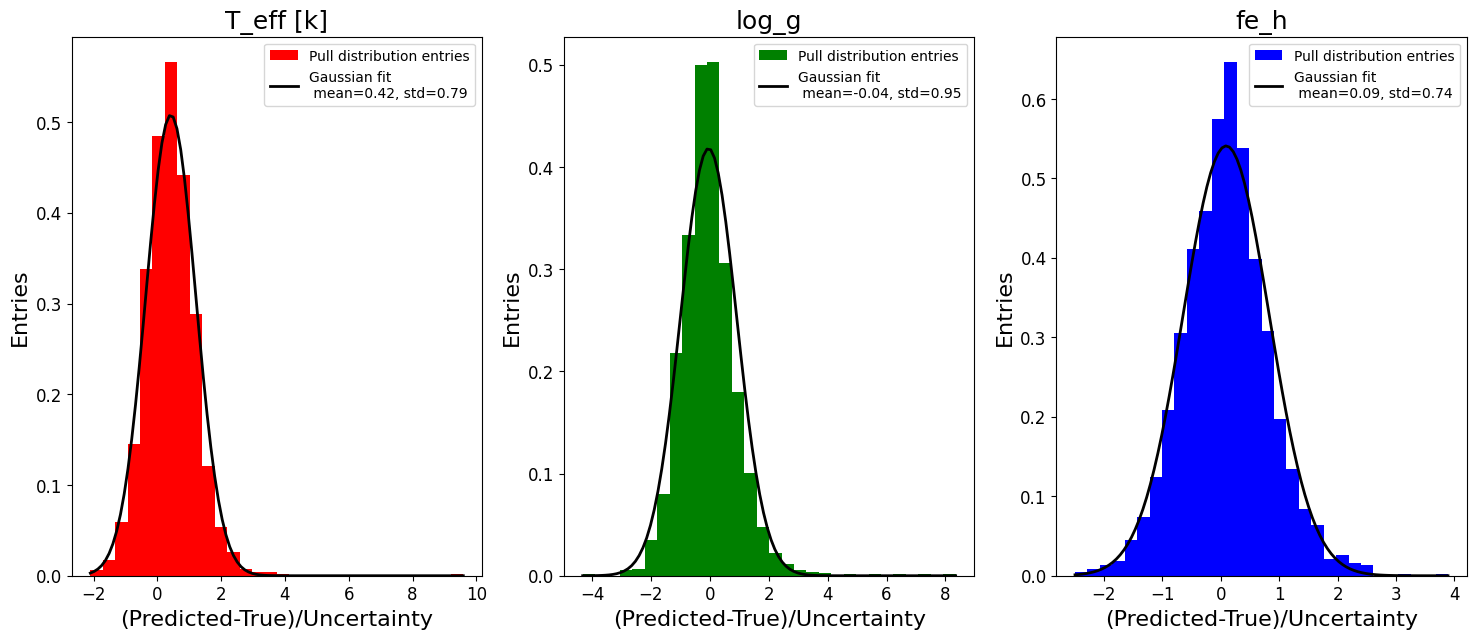

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (18,7))
ax = ax.flatten()

ax[0].hist(pull_val_3[:,0], bins=30, density=True, color='red', label = 'Pull distribution entries')
ax[0].plot(x_range_1_3, curve_fit_1_3, 'black', lw=2, label=f'Gaussian fit\n mean={mu_1_3:.2f}, std={std_1_3:.2f}')
ax[0].set_title('T_eff [k]')
ax[0].set_xlabel('(Predicted-True)/Uncertainty')
ax[0].set_ylabel('Entries')
ax[0].legend(fontsize = 10)

ax[1].hist(pull_val_3[:,1], bins=30, density=True, color='green', label = 'Pull distribution entries')
ax[1].plot(x_range_2_3, curve_fit_2_3, 'black', lw=2, label=f'Gaussian fit\n mean={mu_2_3:.2f}, std={std_2_3:.2f}')
ax[1].set_title('log_g')
ax[1].set_xlabel('(Predicted-True)/Uncertainty')
ax[1].set_ylabel('Entries')
ax[1].legend(fontsize = 10)

ax[2].hist(pull_val_3[:,2], bins=30, density=True, color='blue', label = 'Pull distribution entries')
ax[2].plot(x_range_3_3, curve_fit_3_3, 'black', lw=2, label=f'Gaussian fit\n mean={mu_3_3:.2f}, std={std_3_3:.2f}')
ax[2].set_title('fe_h')
ax[2].set_xlabel('(Predicted-True)/Uncertainty')
ax[2].set_ylabel('Entries')
ax[2].legend(fontsize = 10)

plt.show()

**Visualize predicted PDF**

In [ ]:
model_3.eval()
with torch.no_grad():

    feature, label = next(iter(test_loader)) #Make the loader an iterable and extract the first available element

    feature = feature.unsqueeze(1).float().to(device)
    label = label.float().to(device)

    #Choose three different indexes to pick three random batch elements
    batch_size = feature.shape[0]
    random_indices = random.sample(range(batch_size), k=3)

    # Loop on indeces and visualize the Predicted PDFs
    for idx in random_indices:
        filename = f"{DATA_PATH_2}full_flow_{idx}.png"

        model.visualize_pdf(
            input_data=feature,
            filename=filename,
            samplesize=2000,
            batch_index=idx,
            truth=label[idx]
        )